In [1]:
# Mudança na API do Keras, o Keras Preprocessing está OBSOLETO!
# tensorflow.keras.preprocessing.classeQuePrecisar não deve ser usado
# https://github.com/keras-team/keras-preprocessing?tab=readme-ov-file

# Deve ser usado as Camadas de Pré-processamento do Keras 3 para chamar as funções de transformação!
# tensorflow.keras.layers.classeQuePrecisar
# https://keras.io/api/layers/preprocessing_layers/#image-augmentation-layers

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import os


2024-11-05 10:28:58.150112: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

In [3]:
# Keras usa a biblioteca PIL
# import PIL
# print(PIL.__version__)
from PIL import Image

try:
    pil_image = Image.open(mask_path)
    print("PIL Image opened successfully")
    print("Original size:", pil_image.size)
except Exception as e:
    print(f"Error opening image with PIL: {e}")


PIL Image opened successfully
Original size: (1920, 1080)


In [4]:
# Teste com Tensorflow
try:
    image_original = tf.keras.utils.load_img(mask_path)
    print("TensorFlow load_img successful")
    print("Original size:", image_original.size)
except Exception as e:
    print(f"Error with tf.keras.utils.load_img: {e}")

TensorFlow load_img successful
Original size: (1920, 1080)


Tamanho original: (1920, 1080)
Tamanho redimensionado: (910, 512)


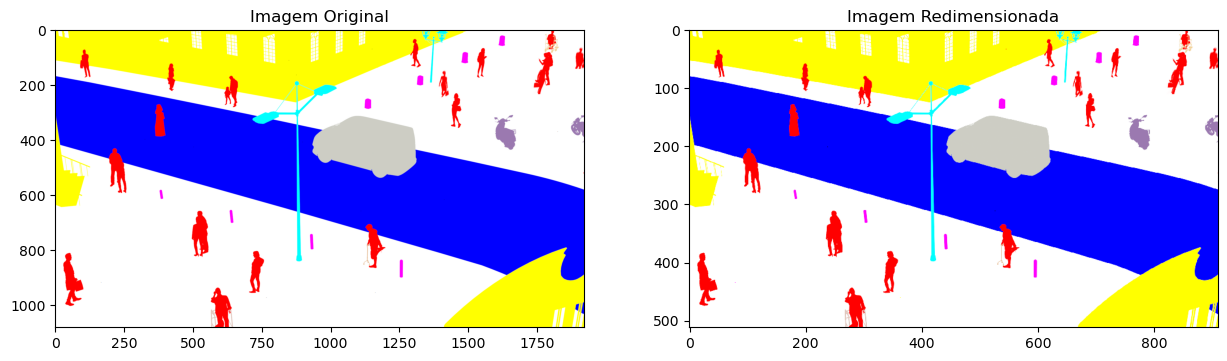

In [ ]:
# Documentação sobre como carregar imagens
# https://keras.io/api/data_loading/image/

# Por hora iniciarei os testes de forma singular usando "load_img, img_to_array, save_img, array_to_img"

# Carregamento de imagem
# Imagem original (1920x1080)
image_original = tf.keras.utils.load_img(mask_path)
print("Tamanho original:", image_original.size)

# Redimensionamento para 910x512 na própria função de carregamento
image_resized = tf.keras.utils.load_img(
    mask_path, 
    target_size=(512, 910)  # (altura, largura)
)
print("Tamanho redimensionado:", image_resized.size)

# Visualização
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.title('Imagem Original')
plt.imshow(image_original)
plt.subplot(1,2,2)
plt.title('Imagem Redimensionada')
plt.imshow(image_resized)
plt.show()


Found 11 files.
Formato do dataset: TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)
Nomes das classes: None


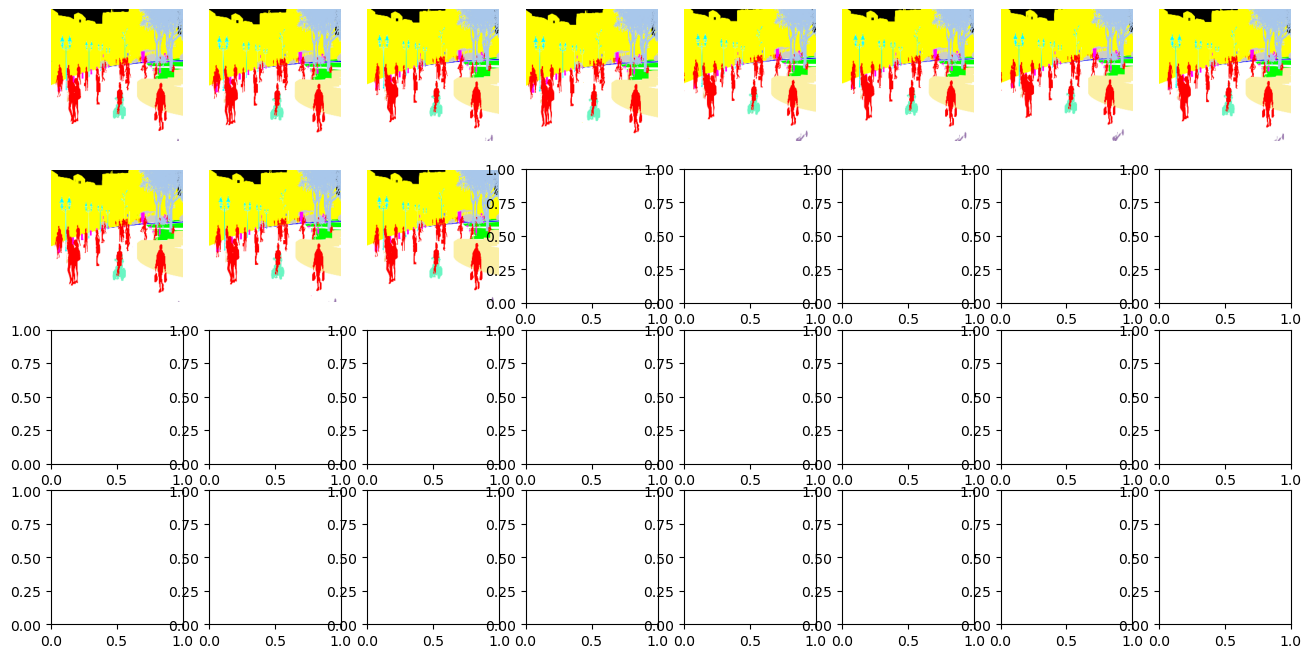

2024-11-05 14:30:13.493094: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [17]:
# ImageDataGenerator está OBSOLETO
# from keras.src.legacy.preprocessing.image import ImageDataGenerator

# Devo usar "image_dataset_from_directory" no lugar do ImageDataGenerator.
# A ideia é carregar o conjunto de dados por essa função e tratar o aumento de dados na sequência do programa.

import tensorflow as tf
from tensorflow import keras

# Carrega o dataset de imagens
dataset = keras.utils.image_dataset_from_directory(
    "/home/renato/Pictures/PIBIC/Dataset",
    # labels="inferred",
    labels=None,
    # label_mode="int",
    label_mode=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=42
)

# Inspeciona o dataset
print("Formato do dataset:", dataset.element_spec)
# print("Número de classes:", len(dataset.class_names))
print("Nomes das classes:", dataset.class_names)

# Visualiza algumas imagens
import matplotlib.pyplot as plt

# for images, labels in dataset.take(1):
for images in dataset.take(1):
    fig, axes = plt.subplots(4, 8, figsize=(16, 8))
    # for i, ax in enumerate(axes.flat):
    for i, ax in enumerate(axes.flat[:len(images)]):
        # ax.imshow(images[i])
        ax.imshow(images[i].numpy().astype("uint8"))
        ax.axis("off")
        # ax.set_title(dataset.class_names[labels[i]])
    plt.show()



In [15]:
print("/home/renato/Pictures/PIBIC/Dataset")
import os
print(os.path.exists("/home/renato/Pictures/PIBIC/Dataset"))
print(os.listdir("/home/renato/Pictures/PIBIC/Dataset"))


/home/renato/Pictures/PIBIC/Dataset
True
['220.png', '219.png', '215.png', '218.png', '222.png', '214.png', '217.png', '213.png', '216.png', '221.png', '212.png']
